In [4]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [5]:
import pandas as pd

df = pd.read_json(
    "../data/raw/ember2018/train_features_0.jsonl",
    lines=True
)

print(df.shape)
df.head()

(50000, 14)


,sha256,md5,appeared,label,avclass,histogram,byteentropy,strings,general,header,section,imports,exports,datadirectories
0,0abb4fda7d5b13801d63bee53e5e256be43e141faa077a...,63956d6417f8f43357d9a8e79e52257e,2006-12,0,,"[45521, 13095, 12167, 12496, 12429, 11709, 118...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'numstrings': 14573, 'avlength': 5.9720716393...","{'size': 3101705, 'vsize': 380928, 'has_debug'...","{'coff': {'timestamp': 1124149349, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...","{'KERNEL32.dll': ['SetFileTime', 'CompareFileT...",[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."
1,c9cafff8a596ba8a80bafb4ba8ae6f2ef3329d95b85f15...,6f7bde7a1126debf0cc359a54953efc1,2007-01,0,,"[93059, 15789, 2871, 3005, 4107, 1771, 2918, 4...","[47100, 2, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0,...","{'numstrings': 1803, 'avlength': 11.1913477537...","{'size': 504320, 'vsize': 524288, 'has_debug':...","{'coff': {'timestamp': 1091600092, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...",{'ADVAPI32.dll': ['ConvertStringSecurityDescri...,[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."
2,eac8ddb4970f8af985742973d6f0e06902d42a3684d791...,7520c8f9534ca818726a4feaebf49e2b,2007-02,0,,"[45369, 2560, 1233, 1542, 4234, 515, 613, 1542...","[6144, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'numstrings': 1238, 'avlength': 12.0201938610...","{'size': 180224, 'vsize': 180224, 'has_debug':...","{'coff': {'timestamp': 892092777, 'machine': '...","{'entry': '.text', 'sections': [{'name': '.tex...","{'ADVAPI32.dll': ['RegSetValueExA', 'RegDelete...",[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."
3,7f513818bcc276c531af2e641c597744da807e21cc1160...,e435a536968941854bcec3b902c439f6,2007-02,0,,"[21315, 9641, 9332, 9358, 9598, 9220, 9146, 93...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'numstrings': 11166, 'avlength': 5.8078989790...","{'size': 2377730, 'vsize': 77824, 'has_debug':...","{'coff': {'timestamp': 708992537, 'machine': '...","{'entry': 'CODE', 'sections': [{'name': 'CODE'...","{'kernel32.dll': ['DeleteCriticalSection', 'Wr...",[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."
4,ca65e1c387a4cc9e7d8a8ce12bf1bcf9f534c9032b9d95...,e93049e2df82ab26f35ad0049173cb14,2007-02,0,,"[23539, 6015, 5214, 4727, 4892, 4649, 4367, 52...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'numstrings': 5547, 'avlength': 6.04344690823...","{'size': 1153808, 'vsize': 1167360, 'has_debug...","{'coff': {'timestamp': 938258311, 'machine': '...","{'entry': '.text', 'sections': [{'name': '.tex...","{'ADVAPI32.dll': ['RegCloseKey', 'AllocateAndI...",[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."


In [6]:
df.tail()

,sha256,md5,appeared,label,avclass,histogram,byteentropy,strings,general,header,section,imports,exports,datadirectories
49995,ec86d25cbc434941f369e595ae3726f742ed4fa4c0627d...,629dd19460268bb8c83e638cfdd59ba3,2017-12,0,,"[667130, 54018, 74358, 33369, 49491, 21827, 63...","[38881, 16368, 14, 4, 3, 4094, 4099, 2051, 3, ...","{'numstrings': 14179, 'avlength': 16.682135552...","{'size': 2211328, 'vsize': 2236416, 'has_debug...","{'coff': {'timestamp': 1476949621, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...",{'mscoree.dll': ['_CorDllMain']},[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."
49996,90fe281ce98183d0693fa3bc03cf8064ad681201dedea2...,68f6d5756d910369f601a679de086160,2017-12,0,,"[1805999, 214832, 166881, 42292, 62705, 22781,...","[8148, 0, 8110, 0, 0, 99, 10, 9, 0, 0, 1, 0, 2...","{'numstrings': 18378, 'avlength': 35.991946893...","{'size': 6655488, 'vsize': 6684672, 'has_debug...","{'coff': {'timestamp': 1513671447, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...",{'mscoree.dll': ['_CorExeMain']},[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."
49997,32d9063bd1354552612d4b6ecbb3ff28940162c9274d52...,23b30e89408c1b8f405c5c5fa2740d20,2017-12,0,,"[2914, 71, 16, 11, 16, 7, 16, 4, 10, 2, 3, 6, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'numstrings': 38, 'avlength': 19.052631578947...","{'size': 4608, 'vsize': 32768, 'has_debug': 0,...","{'coff': {'timestamp': 1492777073, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...",{'mscoree.dll': ['_CorDllMain']},[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."
49998,cd6132884a03b220a94a2cb090e13c7a20d87018375d47...,2f27917338eca29da92417acb31a6271,2017-12,0,,"[19077, 3364, 2370, 961, 1348, 378, 1851, 536,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'numstrings': 699, 'avlength': 16.28755364806...","{'size': 73216, 'vsize': 98304, 'has_debug': 1...","{'coff': {'timestamp': 3811848852, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...",{'mscoree.dll': ['_CorDllMain']},[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."
49999,83db11523f17a9c56a31a3a190cc04a0c714caee92b117...,e12ba603bd2db53ff70523aac2bc2a65,2017-12,0,,"[3688, 338, 167, 80, 142, 59, 33, 23, 35, 31, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'numstrings': 117, 'avlength': 14.20512820512...","{'size': 8192, 'vsize': 32768, 'has_debug': 0,...","{'coff': {'timestamp': 1208922844, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...",{'mscoree.dll': ['_CorDllMain']},[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   sha256           50000 non-null  str   
 1   md5              50000 non-null  str   
 2   appeared         50000 non-null  str   
 3   label            50000 non-null  int64 
 4   avclass          50000 non-null  str   
 5   histogram        50000 non-null  object
 6   byteentropy      50000 non-null  object
 7   strings          50000 non-null  object
 8   general          50000 non-null  object
 9   header           50000 non-null  object
 10  section          50000 non-null  object
 11  imports          50000 non-null  object
 12  exports          50000 non-null  object
 13  datadirectories  50000 non-null  object
dtypes: int64(1), object(9), str(4)
memory usage: 5.3+ MB


In [8]:
df.dtypes

sha256                str
md5                   str
appeared              str
label               int64
avclass               str
histogram          object
byteentropy        object
strings            object
general            object
header             object
section            object
imports            object
exports            object
datadirectories    object
dtype: object

In [9]:
missing = df.isnull().sum()
missing = missing[missing > 0]

print(missing)

Series([], dtype: int64)


In [13]:
print(df["label"].value_counts())

label
 0    102338
 1     63713
-1     42107
Name: count, dtype: int64


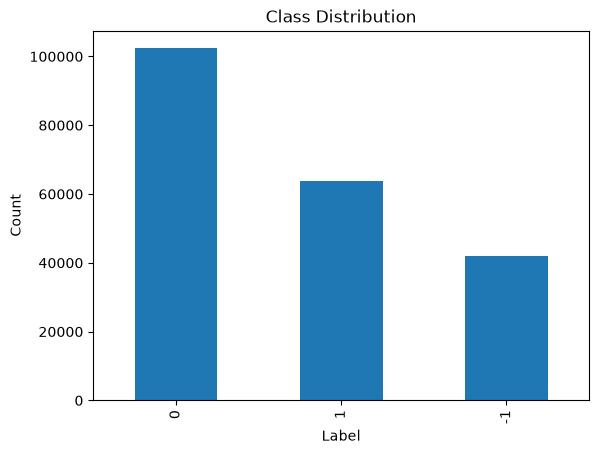

In [14]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [15]:
df.describe()

,label
count,208158.000000
mean,0.103796
std,0.705402
min,-1.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [16]:
print(df.memory_usage(deep=True).sum() / 1024**2, "MB")

1288.6156854629517 MB


In [17]:
print(df.columns.tolist())

['sha256', 'md5', 'appeared', 'label', 'avclass', 'histogram', 'byteentropy', 'strings', 'general', 'header', 'section', 'imports', 'exports', 'datadirectories']


In [18]:
numeric_cols = df.select_dtypes(include="number").columns
print(numeric_cols)

Index(['label'], dtype='str')


In [24]:
for col in df.columns:
    print(col)

sha256
md5
appeared
label
avclass
histogram
byteentropy
strings
general
header
section
imports
exports
datadirectories


In [15]:
import pandas as pd
import os

os.makedirs("../reports/summaries", exist_ok=True)

summary = pd.DataFrame({
    "Dataset": ["train_features_0"],
    "Rows": [df.shape[0]],
    "Columns": [df.shape[1]],
    "Missing Values": [df.isnull().sum().sum()],
    "Duplicate SHA256": [df["sha256"].duplicated().sum()],
    "Memory (MB)": [round(df.memory_usage(deep=True).sum()/(1024**2), 2)],
    "Malware Samples": [(df["label"] == 1).sum()],
    "Benign Samples": [(df["label"] == 0).sum()],
    "Unknown Samples": [(df["label"] == -1).sum()]
})

summary.to_csv("../reports/summaries/train_0_summary.csv", index=False)

print("Summary Saved!")

Summary Saved!
